In [1]:
import tools

In [2]:
import time

In [3]:
tools.ext.np.set_printoptions(precision=8, suppress=True, floatmode="fixed")

In [4]:
! dcm2niix -b y "../../../sourcedata/sub-1/ses-4/PRONE/Dicom/DICOM/"

Chris Rorden's dcm2niiX version v1.0.20220720  (JP2:OpenJPEG) GCC13.2.0 x86-64 (64-bit Linux)
Found 10 DICOM file(s)
Philips Scaling Values RS:RI:SS = 3.32674:0:0.0206128 (see PMC3998685)
Convert 1 DICOM as ../../../sourcedata/sub-1/ses-4/PRONE/Dicom/DICOM/DICOM_WIP_CS_T1-256_20241120120343_301b (512x512x160x1)
Philips Scaling Values RS:RI:SS = 3.32674:0:0.0206128 (see PMC3998685)
Convert 1 DICOM as ../../../sourcedata/sub-1/ses-4/PRONE/Dicom/DICOM/DICOM_CORO_256_20241120120343_303b (512x512x256x1)
Philips Scaling Values RS:RI:SS = 3.32674:0:0.0206128 (see PMC3998685)
Convert 1 DICOM as ../../../sourcedata/sub-1/ses-4/PRONE/Dicom/DICOM/DICOM_SAG_256_20241120120343_305b (512x512x256x1)
Skipping non-image DICOM: ../../../sourcedata/sub-1/ses-4/PRONE/Dicom/DICOM/XX_0003
Skipping non-image DICOM: ../../../sourcedata/sub-1/ses-4/PRONE/Dicom/DICOM/XX_0010
Philips Scaling Values RS:RI:SS = 3.32674:0:0.0206128 (see PMC3998685)
Convert 1 DICOM as ../../../sourcedata/sub-1/ses-4/PRONE/Dicom/DICO

In [5]:
fn1 = "../../../sourcedata/sub-1/ses-4/PRONE/Dicom/DICOM/DICOM_CORO_256_20241120120343_303.nii"
vol1 = tools.ext.nib.load(fn1)

In [6]:
A1 = vol1.get_fdata()
aff1 = vol1.affine
print(A1.shape)

(512, 256, 512)


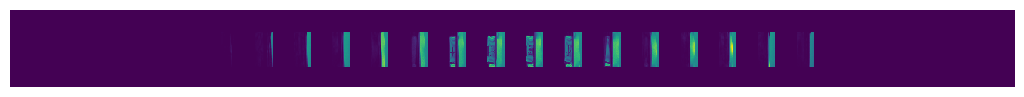

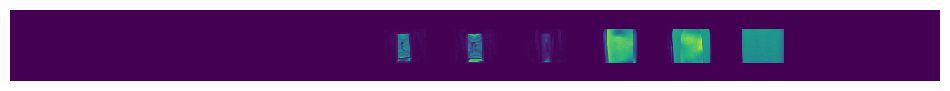

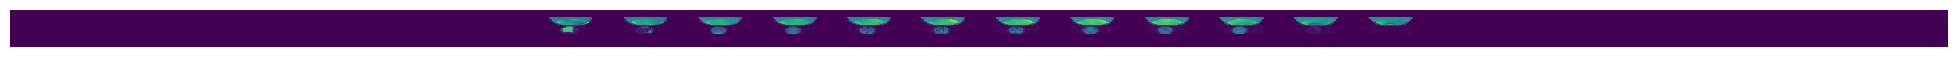

In [7]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A1, mode, 20, decimate=5); 

(112, 66, 82)


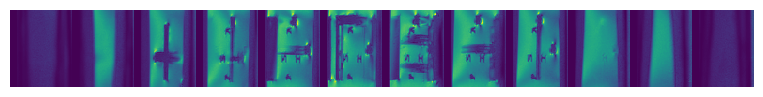

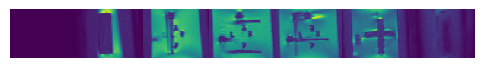

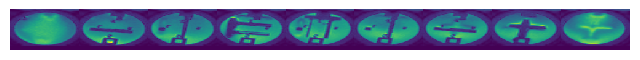

In [8]:
A1r = A1[200:-200, 80:-110, 200:-230]
print(A1r.shape)
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A1r, mode, 10, decimate=1); 

In [9]:
print(aff1)

[[   0.49891877   -0.03954741    0.02624972 -127.11161804]
 [   0.01963926    0.99920940    0.00307207 -224.92048645]
 [  -0.02635046   -0.00406875    0.49930102 -101.59144592]
 [   0.00000000    0.00000000    0.00000000    1.00000000]]


In [10]:
tools.ext.np.sum(aff1 ** 2, 0) ** 0.5

array([  0.49999999,   0.99999999,   0.49999999, 277.61197840])

In [11]:
t1 = time.time()
(A2, aff2) = tools.compute_subresolution_A1_aligned(
    # A1, (0.391, 0.391, 0.391), (2.5, 2.5, 2.5), nrand=1000)
    A1r, (0.5, 1, 0.5), (1.25, 1.25, 1.25), nrand=1000)
t2 = time.time()
print(t2 - t1)

99.74452567100525


In [12]:
A2.shape

(45, 53, 33)

In [14]:
(A0, aff0) = tools.load_template("../templates/template-phantom-mri_resolution-1250.nii.gz")

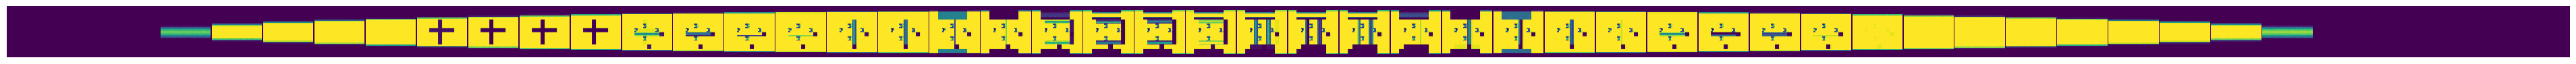

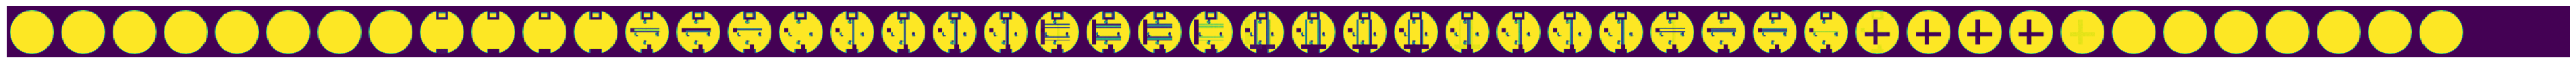

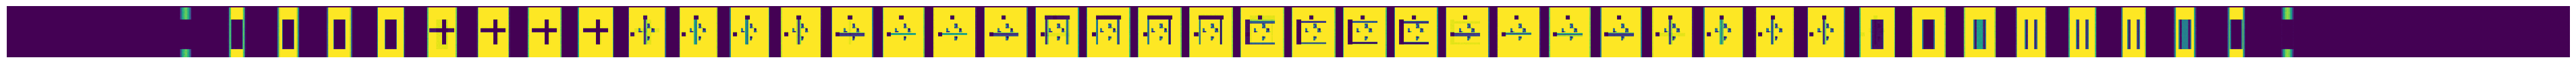

In [15]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A0, mode); 

In [16]:
A0.shape

(49, 49, 49)

In [17]:
A0r = A0[9:-9, 9:-9, 9:-9]
print(A0r.shape)
patterns = tools.compute_patterns(A0r)

(31, 31, 31)


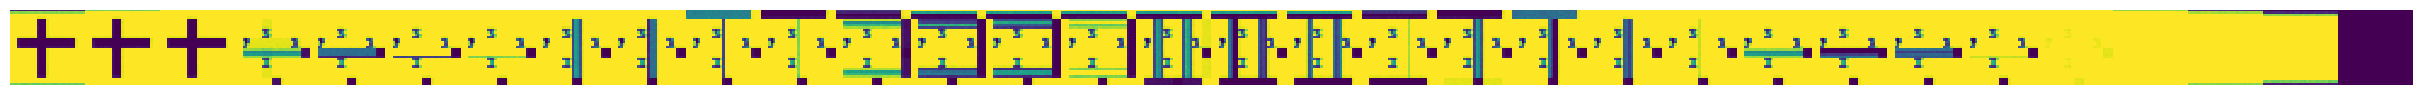

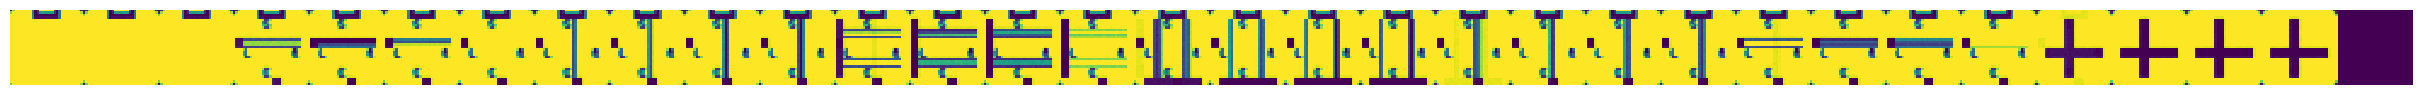

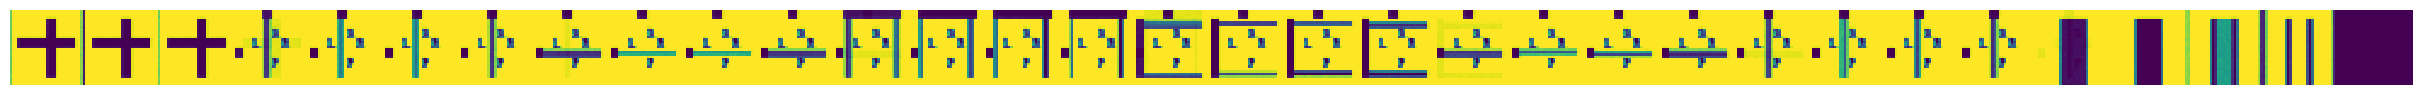

In [18]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A0r, mode); 

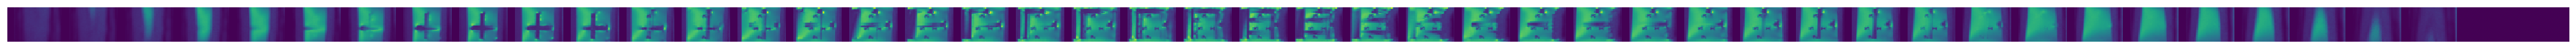

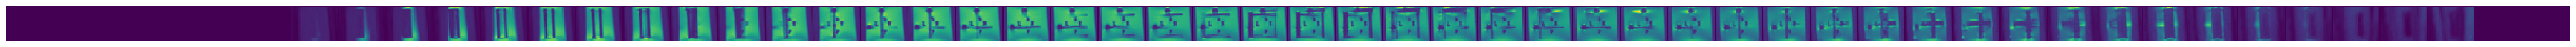

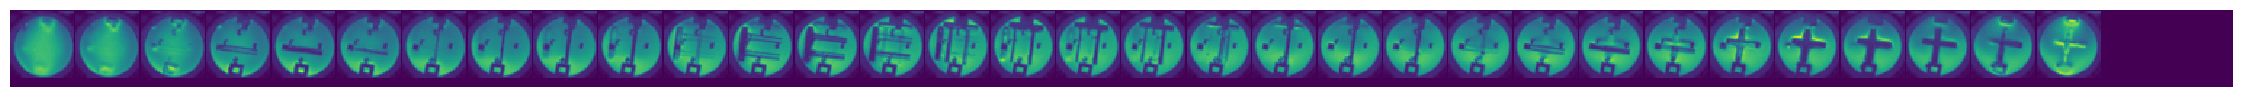

In [19]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A2, mode, decimate=1); 

In [20]:
res = {}
t1 = time.time()
for k in patterns: 
    Ak = patterns[k]
    ck = tools.compute_A_inside_B_best_translation(Ak, A2)
    res[k] = {"i": ck[0], "j": ck[1], "k": ck[2], "c": ck[3]}
t2 = time.time()
print(t2 - t1)
df1 = tools.ext.pd.DataFrame(res)
df2 = df1.T
df3 = df2.sort_values(by="c")

3.859130859375


In [21]:
df3

,i,j,k,c
"False_False_False_(1, 0, 2)",10.0,12.0,0.0,0.871869
"False_True_True_(2, 1, 0)",5.0,13.0,1.0,0.872563
"False_True_False_(2, 1, 0)",6.0,13.0,1.0,0.873303
"True_True_True_(0, 1, 2)",5.0,12.0,1.0,0.873585
"True_False_False_(1, 0, 2)",6.0,13.0,1.0,0.874523
"False_False_False_(2, 1, 0)",7.0,11.0,1.0,0.874801
"True_False_True_(1, 0, 2)",6.0,12.0,1.0,0.876401
"False_False_True_(1, 0, 2)",5.0,13.0,0.0,0.876917
"True_False_True_(0, 1, 2)",6.0,14.0,1.0,0.877255
"True_True_False_(0, 1, 2)",5.0,11.0,1.0,0.877740


In [22]:
print(aff1)

[[   0.49891877   -0.03954741    0.02624972 -127.11161804]
 [   0.01963926    0.99920940    0.00307207 -224.92048645]
 [  -0.02635046   -0.00406875    0.49930102 -101.59144592]
 [   0.00000000    0.00000000    0.00000000    1.00000000]]


In [23]:
(flips1, orientations1) = tools.compute_flips_permutations(aff1)
print(flips1, orientations1)

[False, False, False] [np.int64(0), np.int64(1), np.int64(2)]


In [24]:
(flips2, orientations2) = ([False, False, True], [0, 2, 1])

In [25]:
tools.test_flips_orientations(flips1, flips2, orientations1, orientations2)

'..F.FF'

In [26]:
aff1r = tools.compute_transformed_affine(aff1, flips2, orientations2) 

In [27]:
vol1 = tools.ext.nib.Nifti1Image(A1, aff1r)

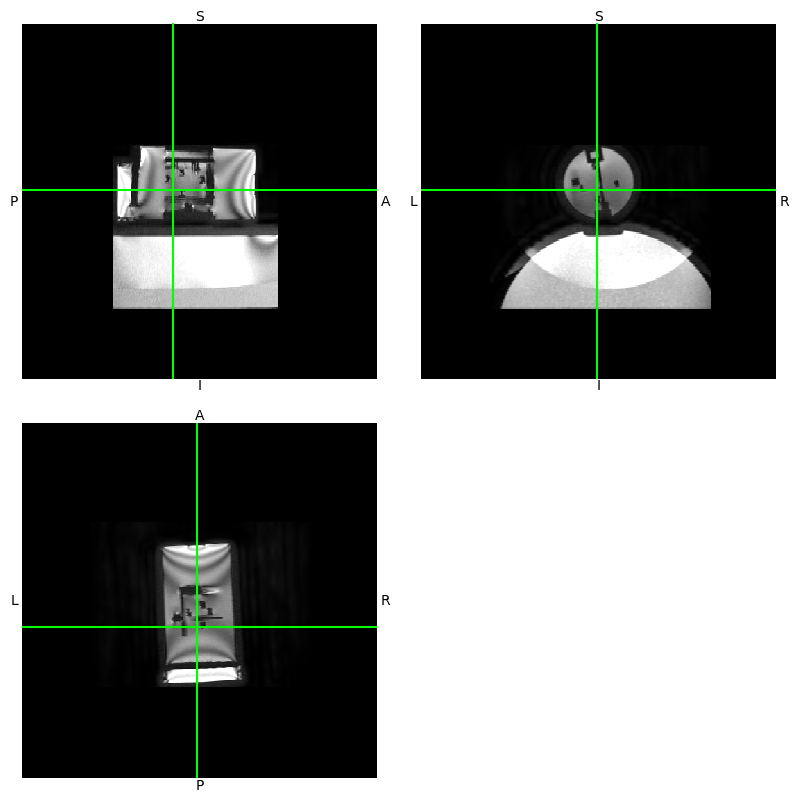

In [28]:
ov1 = vol1.orthoview()
ov1.set_position(0, 0, 100)